# Assignment 01 — Loading and visualizing NYC POPS data

**Student:** Krishna Goyal  
**Dataset:** NYC Department of City Planning, Privately Owned Public Spaces (POPS)  
**NYC Open Data endpoint:** https://data.cityofnewyork.us/resource/rvih-nhyn  
**Included snapshot:** August 6, 2026

## Research question

How do legally documented plaza area and amenity requirements vary among fifteen outdoor POPS along Sixth Avenue, and how does this small corridor sit within the larger Manhattan POPS inventory?

This notebook focuses on two related attributes: **documented plaza area** and **documented amenity provision**. These describe the official record, not current comfort, maintenance, or actual public use.

In [1]:
%matplotlib inline
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

def first_existing(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these paths exist: {candidates}")

## 1. Load the source snapshot and corridor subset

The full snapshot preserves the citywide source used for context. The processed file is a reproducible subset of fifteen developments on Sixth Avenue containing an outdoor plaza component. Keeping both visible prevents the corridor from being mistaken for the entire POPS system.

In [2]:
raw_path = first_existing([
    "pops_raw_snapshot.csv",
    "Final_POPs/data/raw/pops_raw.csv",
    "content/Assignments/Final_POPs/data/raw/pops_raw.csv",
])
corridor_path = first_existing([
    "sixth_avenue_outdoor_pops.csv",
    "Final_POPs/data/processed/sixth_avenue_outdoor_pops.csv",
    "content/Assignments/Final_POPs/data/processed/sixth_avenue_outdoor_pops.csv",
])

raw = pd.read_csv(raw_path)
corridor = pd.read_csv(corridor_path)

print(f"Full NYC snapshot: {len(raw):,} records")
print(f"Manhattan records: {(raw['borough_name'] == 'Manhattan').sum():,}")
print(f"Sixth Avenue study records: {len(corridor)}")
print()
print("Corridor columns:")
print(corridor.columns.tolist())

Full NYC snapshot: 392 records
Manhattan records: 366
Sixth Avenue study records: 15

Corridor columns:
['pops_number', 'corridor_order', 'address', 'building_name', 'year', 'era', 'public_space_type', 'plaza_area_sf', 'hour_of_access_required', 'has_24h_access', 'accessibility', 'amenity_count', 'amenity_level', 'has_seating', 'has_tables', 'has_landscape', 'has_lighting', 'has_signage', 'has_litter', 'has_water', 'provision_score', 'score_band', 'image_path', 'amenities_required', 'other_required', 'permitted_amenities', 'latitude', 'longitude']


## 2. Inspect metadata and attributes

Each corridor row represents one development with an outdoor plaza. `plaza_area_sf` is the documented area of its plaza components. `provision_score` is a transparent derived measure: seven amenity groups—seating, tables, landscape, lighting, signage, litter receptacles, and water—contribute equally.

The score is useful for comparing the **breadth of legal requirements**. It is not a quality rating and does not prove that any amenity is present today.

In [3]:
display(corridor.sort_values("corridor_order")[[
    "pops_number", "address", "year", "public_space_type", "plaza_area_sf",
    "amenities_required", "provision_score", "score_band"
]].reset_index(drop=True))

summary = corridor[["plaza_area_sf", "amenity_count", "provision_score"]].describe().round(1)
display(summary)

,pops_number,address,year,public_space_type,plaza_area_sf,amenities_required,provision_score,score_band
0,M050060,1095 SIXTH AVENUE,1971,Special Permit Plaza; Subway Concourse,17034.18,Artwork; Bicycle Parking; Drinking Fountain; L...,100,Extensive
1,M050057,1114 SIXTH AVENUE,1971,Arcade; Plaza,19659.59,Bicycle Parking; Drinking Fountain; Lighting; ...,100,Extensive
2,M050055,1133 SIXTH AVENUE,1969,Plaza,5177.00,Litter Receptacles; Planting; Plaque/Sign; Sea...,57,Moderate
3,M050054,1155 SIXTH AVENUE,1983,Arcade; Sidewalk Widening; Urban Plaza,4258.00,Bicycle Parking; Drinking Fountain; Lighting; ...,86,Extensive
4,M050052,1166 SIXTH AVENUE,1972,Arcade; Plaza; Through Block Plaza,22794.50,Artwork; Bicycle Parking; Drinking Fountain; L...,100,Extensive
5,M050048,1185 SIXTH AVENUE,1970,Basement Concourse; Landscaped Pedestrian Plaz...,16129.37,Escalator; Food Service; Lighting; Other Requi...,71,Extensive
6,M050047,1211 SIXTH AVENUE,1973,Plaza; Subway Concourse; Through Block Arcade,21872.00,Escalator; Lighting; None; Retail Frontage; Su...,14,Limited
7,M050043,1221 SIXTH AVENUE,1971,Plaza; Sunken Plaza,28613.17,Bicycle Parking; Lighting; Litter Receptacles;...,86,Extensive
8,M050042,1251 SIXTH AVENUE,1970,Plaza,29819.90,NaN,0,Limited
9,M050037,1285 SIXTH AVENUE,1984,Pedestrian Circulation Space; Sidewalk Widenin...,9944.10,Artwork; Drinking Fountain; Escalator; Lightin...,100,Extensive


,plaza_area_sf,amenity_count,provision_score
count,15.0,15.0,15.0
mean,16032.6,7.2,63.8
std,9535.8,4.8,40.4
min,4258.0,0.0,0.0
25%,6095.8,4.0,35.5
50%,17034.2,9.0,86.0
75%,22333.2,10.5,100.0
max,30171.0,13.0,100.0


## 3. Non-map visualization: amenity coverage

This chart counts how many of the fifteen official records require each amenity group. Counts are appropriate here because the question is about coverage within a fixed sample of fifteen—not the amount, condition, or quality of an amenity.

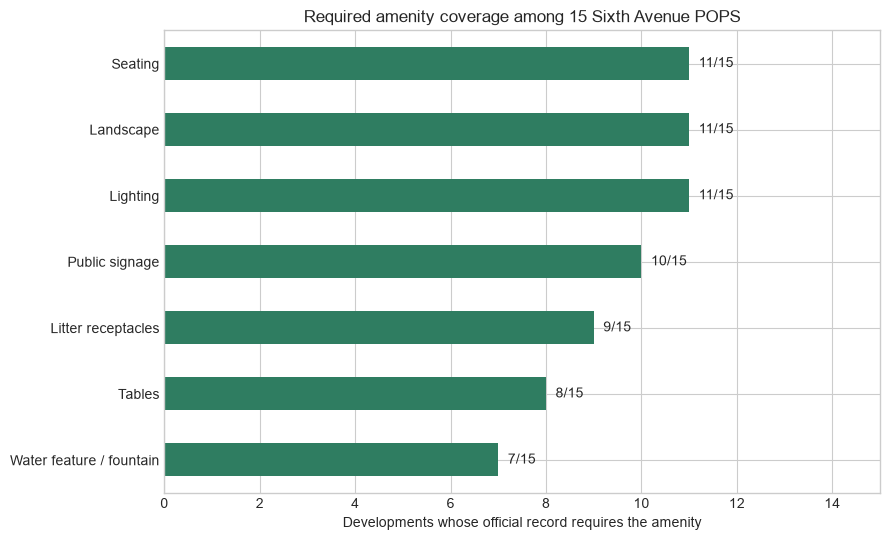

In [4]:
amenity_columns = {
    "Seating": "has_seating",
    "Tables": "has_tables",
    "Landscape": "has_landscape",
    "Lighting": "has_lighting",
    "Public signage": "has_signage",
    "Litter receptacles": "has_litter",
    "Water feature / fountain": "has_water",
}
coverage = pd.Series({label: int(corridor[column].astype(bool).sum()) for label, column in amenity_columns.items()}).sort_values()

ax = coverage.plot(kind="barh", figsize=(9, 5.5), color="#2f7d61")
ax.set(title="Required amenity coverage among 15 Sixth Avenue POPS", xlabel="Developments whose official record requires the amenity", ylabel="")
ax.set_xlim(0, 15)
for index, value in enumerate(coverage):
    ax.text(value + 0.2, index, f"{value}/15", va="center")
plt.tight_layout()
plt.show()

The chart shows that access and support for staying are different questions. All fifteen records include 24-hour access, but seating, tables, water, and other supports are not universal. Because the source stores legal requirements, a missing amenity means “not documented as required,” not necessarily “physically absent.”

## 4. Non-map visualization: area versus provision

Plotting documented area against the provision score tests whether a larger plaza automatically carries a broader amenity program. Labels make the small sample auditable rather than presenting an unexplained trend line.

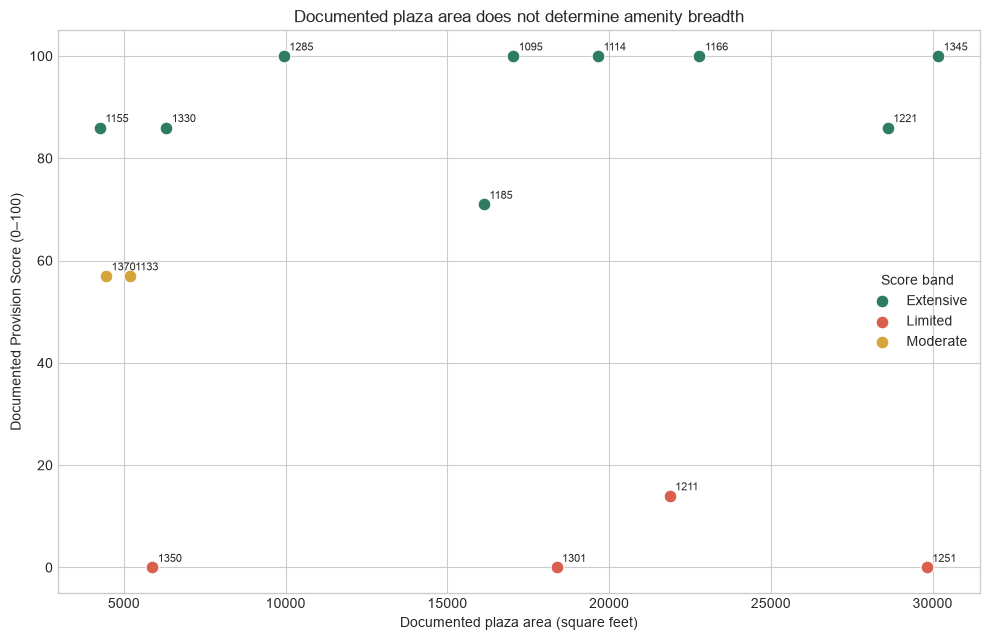

Pearson correlation in this 15-site sample: -0.00


In [5]:
band_colors = {"Limited": "#d95f4f", "Moderate": "#d5a53c", "Extensive": "#2f7d61"}
fig, ax = plt.subplots(figsize=(10, 6.5))
for band, group in corridor.groupby("score_band"):
    ax.scatter(group["plaza_area_sf"], group["provision_score"], s=85, color=band_colors[band], label=band, edgecolor="white", linewidth=0.8)
for _, row in corridor.iterrows():
    ax.annotate(row["address"].split()[0], (row["plaza_area_sf"], row["provision_score"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(title="Documented plaza area does not determine amenity breadth", xlabel="Documented plaza area (square feet)", ylabel="Documented Provision Score (0–100)", ylim=(-5, 105))
ax.legend(title="Score band")
plt.tight_layout()
plt.show()

correlation = corridor["plaza_area_sf"].corr(corridor["provision_score"])
print(f"Pearson correlation in this 15-site sample: {correlation:.2f}")

A correlation from fifteen selected sites is descriptive, not causal. It cannot tell us whether area produced a requirement, whether a requirement was implemented, or whether visitors experience the plaza as welcoming. The labeled points are more important than the single coefficient because they expose exceptions.

## 5. Map visualization: the corridor within Manhattan

The gray points show the wider Manhattan POPS inventory. The selected fifteen are colored by documented provision score. This map answers a positional question—where the study sits—while the charts answer attribute questions.

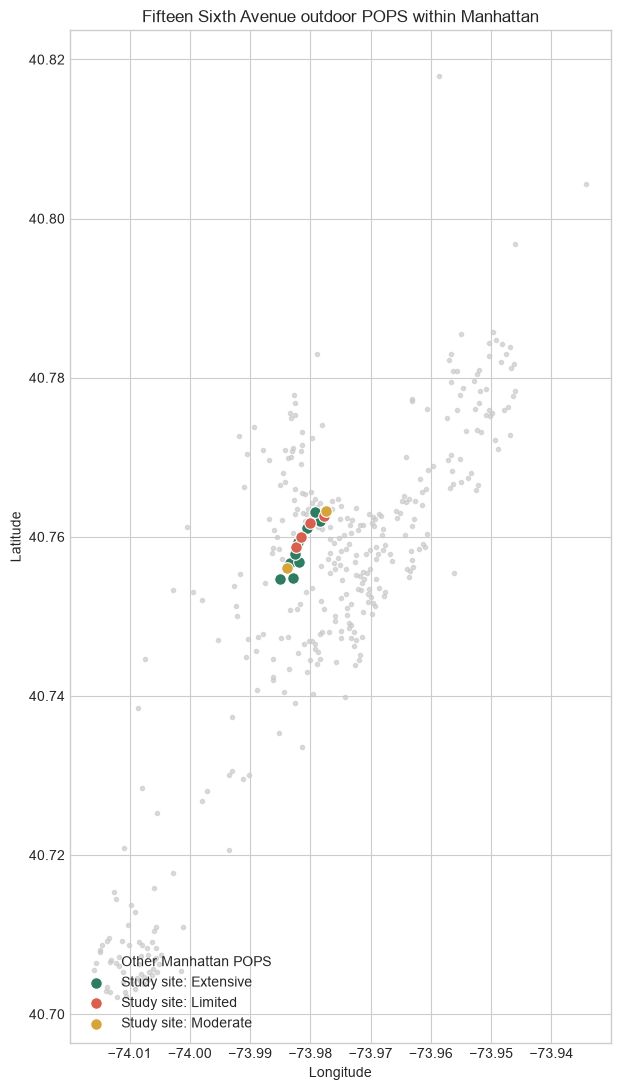

In [6]:
manhattan = raw.loc[raw["borough_name"].eq("Manhattan")].copy()
manhattan = gpd.GeoDataFrame(
    manhattan,
    geometry=gpd.points_from_xy(manhattan["longitude"], manhattan["latitude"]),
    crs="EPSG:4326",
)
corridor_gdf = gpd.GeoDataFrame(
    corridor,
    geometry=gpd.points_from_xy(corridor["longitude"], corridor["latitude"]),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(9, 11))
manhattan.plot(ax=ax, color="#c8c8c8", markersize=9, alpha=0.65, label="Other Manhattan POPS")
for band, group in corridor_gdf.groupby("score_band"):
    group.plot(ax=ax, color=band_colors[band], markersize=70, edgecolor="white", linewidth=0.8, label=f"Study site: {band}")
ax.set(title="Fifteen Sixth Avenue outdoor POPS within Manhattan", xlabel="Longitude", ylabel="Latitude")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Interpretation and limitations

The official inventory can reveal where POPS are recorded, how large their documented components are, and which amenities are legally listed. Within this corridor, access is consistent but amenity breadth is not, and large areas do not automatically imply extensive requirements.

The attributes **cannot** tell us whether amenities are currently installed, maintained, comfortable, accessible, or socially welcoming. They also do not measure how many people use a plaza. Those questions require current imagery, accessibility review, or field observation. The corridor was deliberately selected and is not statistically representative of all Manhattan POPS.